# Nature revision: addressing reviewer concerns

Snippets to address items from `revision/TODO.md`.

## VL107 coverage audit

Set comparison between FLEURS-R languages and VL107 fine-tuning languages.
Three regions: both, FLEURS-only, VL107-only. Match key: ISO 639-1.

In [1]:
import os

os.chdir("../")

In [ ]:
import csv
import re
import unicodedata

from glob import glob
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.colors import LogNorm
from pyglottolog import Glottolog
from pypdf import PdfReader

# --- FLEURS-R side: use glottolog.csv (authoritative for is_ie) ---
# Avoids pyglottolog macrolanguage gaps (lang.iso for `ori`, `fas` etc. is None
# in glottolog's per-language data — the macro entity doesn't carry the iso).
fleurs = (
    pd.read_csv("data/metadata/fleurs-r/n_speakers.csv")
    [["fleurs_dir", "english_name", "ISO_639-1"]]
    .merge(
        pd.read_csv("data/metadata/fleurs-r/glottolog.csv")[["fleurs_dir", "H0"]],
        on="fleurs_dir",
    )
    .rename(columns={"ISO_639-1": "code", "english_name": "name"})
    .assign(is_ie=lambda d: d["H0"] == "indo1319")
    .dropna(subset=["code"])
)
# FLEURS labels spoken Norwegian audio with the written-standard code `nb`.
# Lau et al. 2025 (ACL): FLEURS' nb_no even contains 8.8% Nynorsk text — the
# distinction is unreliable at the text level too.
fleurs["code"] = fleurs["code"].replace({"nb": "no"})
fleurs = fleurs[["code", "name", "is_ie"]].drop_duplicates("code")

# --- VL107 side: pyglottolog ---
g = Glottolog("extern/glottolog")
glot = {}
for lang in g.languoids():
    if lang.iso:
        is_ie = any(parent[1] == "indo1319" for parent in lang.lineage)
        glot[lang.iso] = (lang.name, is_ie)

iso = pd.read_csv("data/resources/iso-639-3.tab", sep="\t")
iso639_1_to_3 = iso.dropna(subset=["Part1"]).set_index("Part1")["Id"].to_dict()

def resolve_vl107(code):
    iso639_3 = iso639_1_to_3.get(code, code)
    name, is_ie = glot.get(iso639_3, (None, False))
    return name, is_ie

vl107_codes = {
    Path(url).stem
    for url in Path("data/datasets/vl107/zip_urls.txt").read_text().splitlines()
    if url.strip()
}
vl107 = pd.DataFrame(
    [(c, *resolve_vl107(c)) for c in sorted(vl107_codes)],
    columns=["code", "name", "is_ie"],
)

# --- Set comparison ---
fleurs_set = set(fleurs["code"])
both_set = fleurs_set & vl107_codes
fleurs_only_set = fleurs_set - vl107_codes
vl107_only_set = vl107_codes - fleurs_set

both = fleurs.query("code in @both_set")
fleurs_only = fleurs.query("code in @fleurs_only_set")
vl107_only = vl107.query("code in @vl107_only_set")

print(f"Both:                  {len(both):3d}  (IE: {both.is_ie.sum()})")
print(f"FLEURS-only:           {len(fleurs_only):3d}  (IE: {fleurs_only.is_ie.sum()})")
print(f"VL107-only:            {len(vl107_only):3d}  (IE: {vl107_only.is_ie.sum()})")

print("\n--- FLEURS-only, IE ---")
print(fleurs_only.query("is_ie")[["code", "name"]].to_string(index=False))
print("\n--- FLEURS-only, non-IE ---")
print(fleurs_only.query("not is_ie")[["code", "name"]].to_string(index=False))
print("\n--- VL107-only, IE ---")
print(vl107_only.query("is_ie")[["code", "name"]].to_string(index=False))
print("\n--- VL107-only, non-IE ---")
print(vl107_only.query("not is_ie")[["code", "name"]].to_string(index=False))

Both:                   79  (IE: 46)
FLEURS-only:            23  (IE: 5)
VL107-only:             28  (IE: 10)

--- FLEURS-only, IE ---
code           name
 ast       Asturian
  ga          Irish
 kea   Kabuverdianu
  or           Odia
 ckb Sorani Kurdish

--- FLEURS-only, non-IE ---
    code             name
yue_hant      Yue Chinese
     fil          Tagalog
      ff            Fulah
      lg          Luganda
      he           Hebrew
      ig             Igbo
      jv         Javanese
     kam            Kamba
      ky           Kyrgyz
     luo              Luo
cmn_hans Mandarin Chinese
     nso           Sepedi
      ny         Chichewa
      om            Oromo
     umb          Umbundu
      wo            Wolof
      xh            Xhosa
      zu             Zulu

--- VL107-only, IE ---
code              name
  br            Breton
  fo           Faroese
  gv              Manx
  ht           Haitian
  la             Latin
  nn Norwegian Nynorsk
  sa          Sanskrit
 sco          

### Summary

**Coverage**: FLEURS-R has 102 langs, VL107 has 107; 79 overlap. Of FLEURS' 51 IE langs, 46 are in VL107 — 5 are out-of-distribution relative to our fine-tuning corpus.

**OOD IE languages in our analysis**:

| Code | Lang | Notes |
|---|---|---|
| `ast` | Asturian | flagged by R1 |
| `ckb` | Sorani Kurdish | VL107 has *no* Kurdish (neither `ku` nor `ckb`); R1 flagged |
| `ga` | Irish | VL107 has `gv` Manx instead — Goidelic sister; R3 flagged |
| `kea` | Kabuverdianu | flagged by R1 |
| `or` | Odia | not flagged by reviewers; found here |

**Other notable cases**:

- **Norwegian**: FLEURS labels spoken Norwegian audio with the written-standard code `nb_no` (Bokmål). Bokmål/Nynorsk is an orthographic distinction that doesn't exist in speech — the audio is just Norwegian, which VL107 covers as `no`. Lau et al. (2025, *Proc. ACL*) document that the label is unreliable even at the text level: FLEURS' `nb_no` contains 8.8% Nynorsk sentences.
- **Welsh** (relevant to the suspect Welsh-English cluster): Welsh *is* in VL107, but three papers report poor-quality Welsh data:
  - Valk & Alumäe (2021, VL107 paper): "the substitution of English with Welsh is more likely caused by the bad quality of the retrieved Welsh data."
  - [TASLP 2022](https://doi.org/10.1109/TASLP.2022.3190736): discarded Welsh from their language set for the same reason.
  - Jia et al. (Titanet-LID/AmberNet)

**VL107-only IE** (languages VL107 covers that FLEURS doesn't — out of scope for our analysis): Albanian, Breton, Faroese, Haitian Creole, Latin, Manx, Norwegian Nynorsk, Sanskrit, Scots, Sinhala.

In [85]:

def to_hours(s):
    s = str(s).strip()
    return 0.5 if s.startswith("<") else float(s)

## XLS-R pretraining coverage

The fine-tuned head is on VL107, but the base XLS-R model is self-supervised pretrained on ~436K hours across multiple corpora (VoxPopuli, MLS, CommonVoice, BABEL, VL107). Per-language pretraining hours are in Babu et al. (2022, *Interspeech*) Table 1.

Audit: for each FLEURS-R IE language, look up its pretraining hours. Flag langs with very low or zero pretraining (these are likely poorly represented even before fine-tuning).

In [ ]:
XLSR_ROW = re.compile(
    r"^([A-Z]\w+(?:\s+[A-Z]\w+)?)"                              # Language
    r"\s+([a-z][\w-]*)"                                         # ISO
    r"\s+(Language isolate|Constructed language|[A-Z][\w-]+)"   # Family
    r"(?:\s+([A-Z][\w-]+(?:\s+[A-Z][\w-]+)?))?"                 # Subgroup (optional)
    r"\s+(<?\d+)\s*$"                                           # Hours
)

# Babu et al. 2022, Table 1 spans pages 4–6 of arxiv:2111.09296
reader = PdfReader("data/resources/2111.09296.pdf")
# text = "\n".join(reader.pages[i].extract_text() for i in [3, 4, 5])

rows = []

for i in [3, 4, 5]:
    lines = reader.pages[i].extract_text().splitlines()
    for line in lines[1:-1]:
        text = unicodedata.normalize("NFKC", line)
        text = re.sub(r"\b([A-Z]) ([a-z])", r"\1\2", text)
        text = re.sub(r"\s*[\u00B4\u0301\u02CA]\s*ı", "í", text)
        try:
            name, iso, family, subgroup, hours = XLSR_ROW.match(text).groups()
            rows.append({"name": name, "code": iso, "hours": hours})
        except AttributeError:
            continue

xlsr_df = pd.DataFrame(rows)
xlsr_df["hours"] = xlsr_df["hours"].apply(to_hours)
xlsr_df.head()

,name,code,hours
0,Abkhazian,ab,0.5
1,Afrikaans,af,87.0
2,Albanian,sq,56.0
3,Amharic,am,65.0
4,Arabic,ar,95.0


In [ ]:
reader = PdfReader("data/resources/vl107.pdf")

lines = reader.pages[3].extract_text().splitlines()[2:]

# a vl 107 row is lang+space+number, repeated 7 times
VL107_PAIR = re.compile(r"([A-Z][\w.]*(?:\s+[A-Z][\w.]*)*?)\s+(\d+)")

vl107_rows = []

for line in lines:
    pairs = VL107_PAIR.findall(line)
    # There should be 7 pairs
    if len(pairs) == 7 or len(pairs) == 6:
        for name, hours in pairs:
            vl107_rows.append({"name": name.strip(), "hours": hours})


vl107_df = pd.DataFrame(vl107_rows).query("name != 'Total' and name != 'Average'")
print(vl107_df.shape)
vl107_df["hours"] = vl107_df["hours"].apply(to_hours)
vl107_df.head()

(107, 2)


,name,hours
0,Abkhazian,10.0
1,Catalan,88.0
2,German,39.0
3,Kannada,46.0
4,Marathi,85.0


In [88]:
# https://github.com/facebookresearch/fairseq/blob/main/examples/wav2vec/README.md
babel_languages = "Assamese, Bengali, Cantonese, Cebuano, Georgian, Haitian, Kazakh, Kurmanji, Lao, Pashto, Swahili, Tagalog, Tamil, Tok, Turkish, Vietnamese, Zulu".split(", ")

# https://catalog.ldc.upenn.edu/byyear
babel_hours = {
    "Assamese": 205,
    "Bengali": 215,
    "Cantonese": 215,
    "Cebuano": 191,
    "Georgian": 190,
    "Haitian": 203,
    "Kazakh": 203,
    "Kurmanji": 203,
    "Lao": 207,
    "Pashto": 244,
    "Swahili": 350,
    "Tagalog": 213,
    "Tamil": 350,
    "Tok": 200,
    "Turkish": 213,
    "Vietnamese": 201,
    "Zulu": 211
}

babel_df = pd.DataFrame.from_dict(babel_hours, orient="index", columns=["hours"]).reset_index(names="name")

babel_df

,name,hours
0,Assamese,205
1,Bengali,215
2,Cantonese,215
3,Cebuano,191
4,Georgian,190
5,Haitian,203
6,Kazakh,203
7,Kurmanji,203
8,Lao,207
9,Pashto,244


In [ ]:
vp_languages = {
    "Bg": "Bulgarian",
    "Cs": "Czech",
    "Hr": "Croatian",
    "Da": "Danish",
    "Nl": "Dutch",
    "En": "English",
    "Et": "Estonian",
    "Fi": "Finnish",
    "Fr": "French",
    "De": "German",
    "El": "Greek",
    "Hu": "Hungarian",
    "It": "Italian",
    "Lv": "Latvian",
    "Lt": "Lithuanian",
    "Mt": "Maltese",
    "Pl": "Polish",
    "Pt": "Portuguese",
    "Ro": "Romanian",
    "Sk": "Slovak",
    "Sl": "Slovene",
    "Es": "Spanish",
    "Sv": "Swedish"
}

reader = PdfReader("data/resources/voxpopuli.pdf")

lines = reader.pages[1].extract_text().splitlines()

# Example row: En 24.1K 543 1313 (29.6) 4.8M 60.1M
NUM = r"(?:[\d.]+[KM]?|-)"                # number with optional K/M, or `-` for missing

VOXPOPULI_ROW = re.compile(
    r"^([A-Z][a-z]+)"                     # Language code (En, Hr, Pt, ...)
    rf"\s+({NUM})"                        # Unlabeled hours
    rf"\s+({NUM})"                        # Transcribed hours
    rf"\s+({NUM})"                        # Speakers
    r"(?:\s+\(([\d.]+)\))?"               # Female % (optional, in parens)
    rf"\s+({NUM})"                        # Transcribed Tokens
    rf"\s+({NUM})\s*$"                    # LM Tokens
)

vp_rows = []

for line in lines:
    match = VOXPOPULI_ROW.match(line)
    if match:
        lang, hours, transcribed_hours, speakers, female, tokens, lm_tokens = match.groups()
        if lang in vp_languages:
            vp_rows.append({
                "code": lang.lower(),
                "name": vp_languages[lang],
                "hours": float(hours.replace("K", "e3")),
            })

vp_df = pd.DataFrame(vp_rows)
print(vp_df.shape)
vp_df

(23, 3)


,code,name,hours
0,en,English,24100.0
1,de,German,23200.0
2,fr,French,22800.0
3,es,Spanish,21400.0
4,pl,Polish,21200.0
5,it,Italian,21900.0
6,ro,Romanian,17900.0
7,hu,Hungarian,17700.0
8,cs,Czech,18700.0
9,nl,Dutch,19000.0


In [ ]:
reader = PdfReader("data/resources/mls.pdf")

lines = reader.pages[4].extract_text().splitlines()

# Example row: English 44,659.74 15.75 15.55 2742 2748 21 21 21 21 7.76 7.99 7.62 7.93
MLS_ROW = re.compile(
    r"^([A-Z][a-z]+)"                     # Language
    r"\s+([\d,]+\.?\d*)"                 # Train hours
    r"\s+([\d.]+)"                       # Dev hours
    r"\s+([\d.]+)"                       # Test hours
    r"\s+(\d+)"
    r"\s+(\d+)"
    r"(?:\s+\d+){4}"
    r"\s+([\d.]+)"
    r"\s+([\d.]+)"
    r"\s+([\d.]+)"
    r"\s+([\d.]+)\s*$"
)

mls_rows = []
for line in lines:
    match = MLS_ROW.match(line)
    if match:
        lang, train_hours, dev_hours, test_hours, *_ = match.groups()
        mls_rows.append({
            "name": lang,
            "hours": float(train_hours.replace(",", "")),
        })

mls_df = pd.DataFrame(mls_rows)
print(mls_df.shape)
mls_df

(8, 2)


,name,hours
0,English,44659.74
1,German,1966.51
2,Dutch,1554.24
3,French,1076.58
4,Spanish,917.68
5,Italian,247.38
6,Portuguese,160.96
7,Polish,103.65


In [253]:
import requests

CHANGELOG_URL = "https://raw.githubusercontent.com/common-voice/cv-dataset/main/datasets/scripted-speech/CHANGELOG.md"
CORPUS_URL = "https://raw.githubusercontent.com/common-voice/cv-dataset/main/datasets/scripted-speech/cv-corpus-6.1-2020-12-11.json"
ANCHOR = "### [Corpus 6.1]"  # newer releases sit above v6.1; we parse from here downward


def build_locale_to_name(changelog_url: str = CHANGELOG_URL, anchor: str = ANCHOR) -> dict[str, str]:
    """Map locale code -> language name, restricted to locales present at the anchor version or earlier."""
    text = requests.get(changelog_url).text
    idx = text.find(anchor)
    if idx == -1:
        raise ValueError(f"Anchor {anchor!r} not found in CHANGELOG")
    section = text[idx:]

    mapping = {"en": "English"}  # English predates the "New languages" tracking
    entry = re.compile(r"([^,]+?)\s*\(`([a-zA-Z][a-zA-Z0-9\-]*)`\)")
    for line in section.splitlines():
        if not line.lstrip().startswith("**New languages"):
            continue
        line = re.sub(r"^\s*\*\*New languages[^*]*\*\*:?\s*", "", line)
        for m in entry.finditer(line):
            code = m.group(2).strip()
            if code not in mapping:
                mapping[code] = m.group(1).strip()
    return mapping


def load_cv_corpus(corpus_url: str = CORPUS_URL) -> pd.DataFrame:
    data = requests.get(corpus_url).json()
    df = (
        pd.DataFrame.from_dict(data["locales"], orient="index")
        .reset_index()
        .rename(columns={"index": "locale"})
    )
    return df[["locale", "totalHrs", "validHrs", "clips", "users"]]


locale_to_name = build_locale_to_name()
cv_df = load_cv_corpus()
cv_df.insert(1, "language", cv_df["locale"].map(locale_to_name))
cv_df = cv_df.sort_values("validHrs", ascending=False).reset_index(drop=True)
cv_df = cv_df.loc[:, ["locale", "language", "validHrs"]].rename(
    columns={
        "locale": "code",
        "language": "name",
        "validHrs": "hours"
    }
)
cv_df = cv_df.replace("Upper", "Upper Sorbian")
cv_df

,code,name,hours
0,en,English,1686.88
1,rw,Kinyarwanda,1183.62
2,de,German,777.20
3,fr,French,623.92
4,ca,Catalan,623.47
5,kab,Kabyle,525.45
6,es,Spanish,324.65
7,fa,Persian,282.63
8,it,Italian,158.35
9,ru,Russian,111.05


In [ ]:
TSV_COLS = ["sentence_index", "fname", "sentence", "sentence_lower",
            "chars", "num_samples", "gender"]

# Sum samples per fleurs_dir (mirrors src/data/datasets.py:78–107)
dfs = []
for tsv in sorted(glob("data/datasets/fleurs-r/*/*/*.tsv")):
    fleurs_dir = Path(tsv).parents[0].stem
    df = pd.read_csv(tsv, sep="\t", names=TSV_COLS, quoting=csv.QUOTE_NONE)
    df["fleurs_dir"] = fleurs_dir
    dfs.append(df)

samples = (
    pd.concat(dfs).dropna()
    .groupby("fleurs_dir")["num_samples"].sum()
    .reset_index()
)

# Join with n_speakers.csv for ISO 639-1 + English name
fleurs_df = (
    pd.read_csv("data/metadata/fleurs-r/n_speakers.csv")
    [["fleurs_dir", "english_name", "ISO_639-1"]]
    .rename(columns={"english_name": "name", "ISO_639-1": "code"})
    .merge(samples, on="fleurs_dir")
    .assign(hours=lambda d: d["num_samples"] / (16_000 * 3600))
    [["code", "name", "hours"]]
    .sort_values("hours", ascending=False)
    .reset_index(drop=True)
)
print(f"{len(fleurs_df)} FLEURS-R languages")
fleurs_df.head()

102 FLEURS-R languages


,code,name,hours
0,mi,Maori,21.313189
1,oc,Occitan,19.104483
2,mr,Marathi,17.084150
3,ln,Lingala,16.817717
4,ig,Igbo,16.779150


In [ ]:
# --- Single source of truth for code normalizations ---
CODE_REMAP = {
    "nb": "no",
    "nn": "no",            # ← Nynorsk → Norwegian (same audio language)
    "zh": "cmn",
    "ku": "kmr",
    "lm": "lb",
    "fil": "tl",
    "yue_hant": "yue",
    "cmn_hans": "cmn",
}

NAME_ALIASES = {
    "Luxembourg.":  "Luxembourgish", "C. Khmer": "Khmer", "Nynorsk": "Norwegian Nynorsk",
    "Kurmanji":     "Northern Kurdish", "Tok": "Tok Pisin", "Cantonese": "Yue Chinese",
    "Pashto":       "Pushto",
    "Greek":        "Modern Greek (1453-)", "Interlingua": "Interlingua (IALA)",
    "Malay":        "Malay (macrolanguage)", "Nepali": "Nepali (macrolanguage)",
    "Occitan":      "Occitan (post 1500)", "Swahili": "Swahili (macrolanguage)",
    "Waray":        "Waray (Philippines)",
}

iso_full = pd.read_csv("data/resources/iso-639-3.tab", sep="\t")

def name_to_iso(name):
    name = NAME_ALIASES.get(name, name)
    row = iso_full[iso_full["Ref_Name"] == name]
    if row.empty:
        return None
    return row["Part1"].iloc[0] if pd.notna(row["Part1"].iloc[0]) else row["Id"].iloc[0]

def normalize_code(s):
    return s.str.split("-").str[0].replace(CODE_REMAP)

# --- Build per-dataset (code, name, hours) ---
vl107_hours = vl107_df.assign(code=lambda d: d["name"].apply(name_to_iso))
mls_hours   = mls_df.assign(code=lambda d: d["name"].apply(name_to_iso))
babel_hours = babel_df.assign(code=lambda d: d["name"].apply(name_to_iso))
voxpopuli_hours = vp_df.rename(columns={vp_df.columns[0]: "code"}).assign(code=lambda d: d["code"].str.lower())
cv_hours = cv_df.assign(code=lambda d: normalize_code(d["code"])).groupby("code", as_index=False)["hours"].sum()
fleurs_hours = fleurs_df.copy()
fleurs_hours["name"] = fleurs_hours["name"].replace({"Norwegian Bokmål": "Norwegian"})
xlsr_hours = (
    xlsr_df.rename(columns={"iso": "code"})
    .assign(hours=lambda d: d["hours"].apply(to_hours), code=lambda d: normalize_code(d["code"]))
    .groupby("code", as_index=False)["hours"].sum()
)

# Apply CODE_REMAP uniformly to all
for df in (fleurs_hours, vl107_hours, mls_hours, babel_hours, cv_hours, voxpopuli_hours, xlsr_hours):
    df["code"] = df["code"].replace(CODE_REMAP)

# --- Outer-join on code ---
sources = {"fleurs": fleurs_hours, "vl107": vl107_hours, "cv": cv_hours, "mls": mls_hours,
           "babel": babel_hours, "voxpopuli": voxpopuli_hours, "xlsr": xlsr_hours}
merged = None
for src, df in sources.items():
    sub = (
        df[["code", "hours"]]
        .dropna(subset=["code"])
        .groupby("code", as_index=False)["hours"].sum()     # ← collapses duplicates after CODE_REMAP
        .rename(columns={"hours": f"hours_{src}"})
    )
    merged = sub if merged is None else merged.merge(sub, on="code", how="outer")

merged["hours_xlsr_pretrain"] = merged[
    ["hours_vl107", "hours_cv", "hours_mls", "hours_babel", "hours_voxpopuli"]
].sum(axis=1, min_count=1)

# --- Names: priority FLEURS > VL107 > Babu > ... > ISO 639-3 fallback ---
names = pd.concat([
    *(d.assign(code=d["code"])[["code", "name"]] for d in [fleurs_hours, vl107_hours, babel_hours, mls_hours]),
    xlsr_df.rename(columns={"iso": "code"}).assign(code=lambda d: normalize_code(d["code"]))[["code", "name"]],
    cv_df.assign(code=lambda d: normalize_code(d["code"]))[["code", "name"]],
    vp_df.rename(columns={vp_df.columns[0]: "code"}).assign(code=lambda d: d["code"].str.lower())[["code", "name"]],
    iso_full.dropna(subset=["Part1"]).rename(columns={"Part1": "code", "Ref_Name": "name"})[["code", "name"]],
    iso_full.rename(columns={"Id": "code", "Ref_Name": "name"})[["code", "name"]],
]).dropna(subset=["code"]).drop_duplicates("code", keep="first")

merged = merged.merge(names, on="code", how="left")
merged = merged[["code", "name", "hours_fleurs", "hours_xlsr", "hours_xlsr_pretrain",
                 "hours_vl107", "hours_cv", "hours_mls", "hours_babel", "hours_voxpopuli"]]
print(merged.shape)
merged.to_csv("data/metadata/fleurs-r/xlsr_coverage.csv", index=False)
merged.head(15)

(137, 10)


,code,name,hours_fleurs,hours_xlsr,hours_xlsr_pretrain,hours_vl107,hours_cv,hours_mls,hours_babel,hours_voxpopuli
0,ab,Abkhazian,NaN,0.5,10.05,10.0,0.05,NaN,NaN,NaN
1,af,Afrikaans,4.103383,87.0,108.00,108.0,NaN,NaN,NaN,NaN
2,am,Amharic,10.616467,65.0,81.00,81.0,NaN,NaN,NaN,NaN
3,ar,Arabic,8.193056,95.0,108.31,59.0,49.31,NaN,NaN,NaN
4,as,Assamese,15.144733,179.0,360.74,155.0,0.74,NaN,205.0,NaN
5,ast,Asturian,10.162550,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,az,North Azerbaijani,12.914417,47.0,58.00,58.0,NaN,NaN,NaN,NaN
7,ba,Bashkir,NaN,47.0,58.00,58.0,NaN,NaN,NaN,NaN
8,be,Belarusian,14.788950,106.0,133.00,133.0,NaN,NaN,NaN,NaN
9,bg,Bulgarian,12.332833,17616.0,17650.00,50.0,NaN,NaN,NaN,17600.0


In [266]:
merged.sum(0, numeric_only=True)

hours_fleurs             1246.787685
hours_xlsr             436284.000000
hours_xlsr_pretrain    451965.430000
hours_vl107              6629.000000
hours_cv                 7335.690000
hours_mls               50686.740000
hours_babel              3814.000000
hours_voxpopuli        383500.000000
dtype: float64

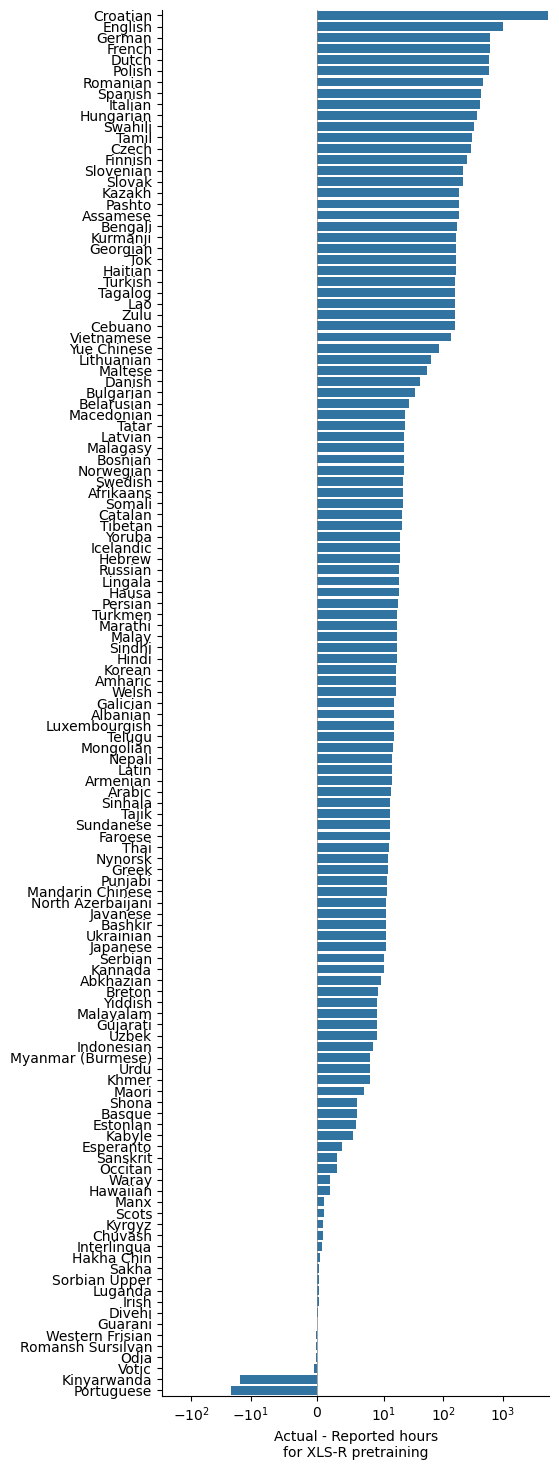

In [ ]:
diff = merged.assign(
    hours_xlsr_diff=lambda d: (d["hours_xlsr_pretrain"] - d["hours_xlsr"])
).loc[:, ["name", "hours_xlsr_diff"]].dropna().sort_values(
    "hours_xlsr_diff", ascending=False
)

# with sns.plotting_context("talk", font_scale=1.1):
fig, ax = plt.subplots(figsize=(5, 18))

sns.barplot(diff, x="hours_xlsr_diff", y="name", ax=ax)
# Rotate x labels for readability
# ax.set_yticklabels(ax.get_yticklabels(), rotation=90)
ax.set_ylabel("")
ax.axvline(0, color="grey", lw=0.5)
ax.set_xscale("symlog", linthresh=10)
ax.set_xlabel("Actual - Reported hours\nfor XLS-R pretraining")
sns.despine()
plt.show()

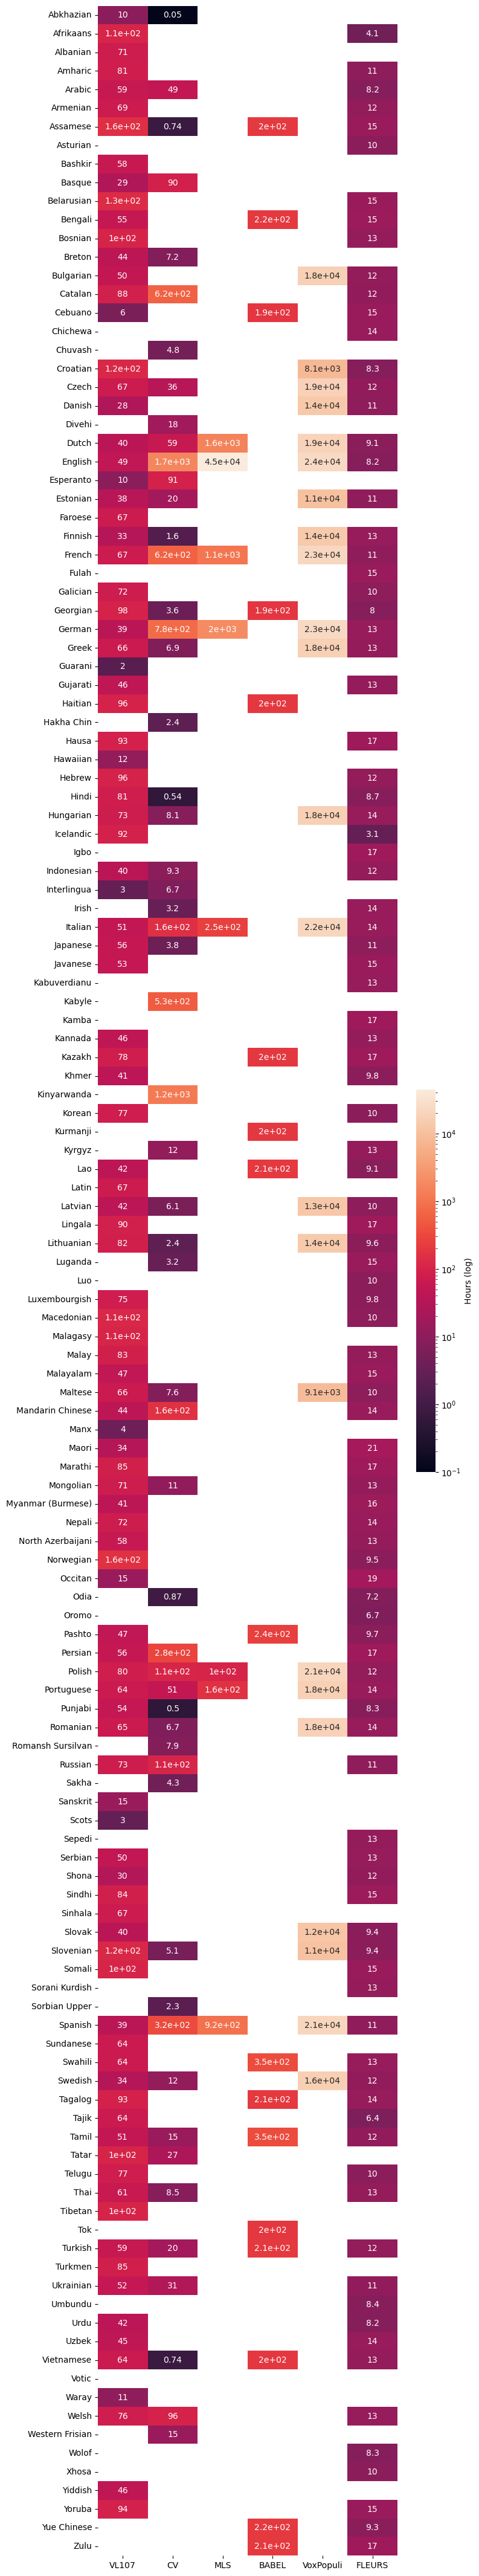

In [ ]:
m = (
    merged[["name", "hours_vl107", "hours_cv", "hours_mls", "hours_babel", "hours_voxpopuli", "hours_fleurs"]]
    .sort_values("name")
    .set_index("name")
)

fig, ax = plt.subplots(figsize=(8, len(m) * 0.4))
sns.heatmap(
    m,
    norm=LogNorm(vmin=0.1, vmax=m.max().max()),
    cbar_kws={"label": "Hours (log)", "shrink": 0.15},
    xticklabels=["VL107", "CV", "MLS", "BABEL", "VoxPopuli", "FLEURS"],
    yticklabels=True,
    annot=True,
    ax=ax,
)
ax.set_ylabel("")
plt.show()

In [272]:
print(merged.query("name == 'Norwegian'"))

   code       name  hours_fleurs  hours_xlsr  hours_xlsr_pretrain  \
87   no  Norwegian      9.464083       130.0                107.0   
88   no  Norwegian      9.464083       130.0                 57.0   

    hours_vl107  hours_cv  hours_mls  hours_babel  hours_voxpopuli  
87        107.0       NaN        NaN          NaN              NaN  
88         57.0       NaN        NaN          NaN              NaN  


In [287]:
merged.query("hours_fleurs.notna() & hours_xlsr < 100").sort_values("hours_xlsr")

,code,name,hours_fleurs,hours_xlsr,hours_xlsr_pretrain,hours_vl107,hours_cv,hours_mls,hours_babel,hours_voxpopuli
92,or,Odia,7.233367,1.0,0.87,NaN,0.87,NaN,NaN,NaN
70,lg,Luganda,15.053767,3.0,3.24,NaN,3.24,NaN,NaN,NaN
37,ga,Irish,13.987567,3.0,3.23,NaN,3.23,NaN,NaN,NaN
67,ky,Kyrgyz,12.956850,11.0,11.94,NaN,11.94,NaN,NaN,NaN
90,oc,Occitan,19.104483,12.0,15.00,15.0,NaN,NaN,NaN,NaN
108,sn,Shona,11.666800,24.0,30.00,30.0,NaN,NaN,NaN,NaN
77,mi,Maori,21.313189,27.0,34.00,34.0,NaN,NaN,NaN,NaN
63,km,Khmer,9.844067,33.0,41.00,41.0,NaN,NaN,NaN,NaN
84,my,Myanmar (Burmese),15.866294,33.0,41.00,41.0,NaN,NaN,NaN,NaN
126,ur,Urdu,8.172250,34.0,42.00,42.0,NaN,NaN,NaN,NaN


In [3]:
genders = pd.read_csv("/home/nclow23/src/phylaudio/public/data/metadata/fleurs-r/genders.csv")

genders.head()

,fleurs_dir,n_recordings_female,n_recordings_male,n_recordings_other,n_samples_female,n_samples_male,n_samples_other,n_recordings_total,pct_female
0,af_za,936.0,550.0,0.0,143233920.0,93120960.0,0.0,1486.0,62.987887
1,am_et,1276.0,1786.0,0.0,216949440.0,394559040.0,0.0,3062.0,41.672110
2,ar_eg,2403.0,418.0,0.0,405547569.0,66372480.0,0.0,2821.0,85.182559
3,as_in,2043.0,2116.0,0.0,386461440.0,485875200.0,0.0,4159.0,49.122385
4,ast_es,1628.0,1936.0,0.0,290691840.0,294671040.0,0.0,3564.0,45.679012


(fleurs_dir
lb_lu     21.169631
sv_se     25.376157
ga_ie     29.860493
km_kh     30.517827
umb_ao    32.669323
Name: pct_female, dtype: float64, fleurs_dir
pa_in    82.923930
ar_eg    85.182559
om_et    89.131685
th_th    89.366516
xh_za    90.197598
Name: pct_female, dtype: float64)


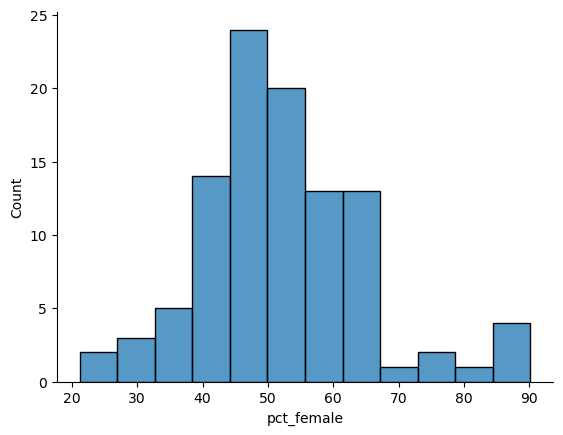

In [4]:
sns.histplot(
    x="pct_female",
    data=genders
)
print((
    genders.set_index("fleurs_dir").pct_female.sort_values().head(),
    genders.set_index("fleurs_dir").pct_female.sort_values().tail()
    )
)
sns.despine()
plt.show()

In [10]:
# Bootstrap 95% confidence for pct_female mean

def bootstrap_ci(data, n_bootstrap=10000, ci=95):
    means = []
    n = len(data)
    for _ in range(n_bootstrap):
        sample = data.sample(n, replace=True)
        means.append(sample.mean())
    lower = pd.Series(means).quantile((100 - ci) / 200)
    upper = pd.Series(means).quantile(1 - (100 - ci) / 200)
    return lower, upper

lo, hi = bootstrap_ci(genders["pct_female"])
print(f"Bootstrap {95}% CI for pct_female mean: {lo:.2f} - {hi:.2f}")
print(f"Mean pct_female: {genders['pct_female'].mean():.2f}")

Bootstrap 95% CI for pct_female mean: 49.90 - 54.90
Mean pct_female: 52.36


## Gender bias analysis

Does speaker sex systematically bias the between-language embedding structure?

Two tests:
1. **PERMANOVA** on the pairwise distance matrix (language + sex as factors) — variance partitioning
2. **Mantel test** — correlation between male-only and female-only distance matrices

In [10]:
import csv
import json
from glob import glob
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from scipy.spatial.distance import pdist, squareform
from skbio import DistanceMatrix
from skbio.stats.distance import permanova, mantel

# ---------- 1. Load raw XLS-R embeddings + project through v7 GELU head ----------
RUN_ID = "67c9af47-6177-4d06-bcc5-7c64b43e4b06"
EMB_DIR = f"data/embeddings/fleurs-r/{RUN_ID}"
CKPT = "data/eval/phylaudio3/v7zqs3lv/checkpoints/epoch=1-step=7754.ckpt"

raw_emb = torch.load(f"{EMB_DIR}/embeddings.pt", weights_only=True).float()
meta = pd.read_parquet(f"{EMB_DIR}/meta.parquet")
taxa = json.load(open(f"{EMB_DIR}/taxa.json"))
fleurs_dirs = taxa["labels"]

meta["fleurs_dir"] = meta["label"].map(lambda i: fleurs_dirs[i])

# Project: Linear(1024→256) + GELU
state = torch.load(CKPT, weights_only=False, map_location="cpu")["state_dict"]
W = state["classifier.projector.0.weight"]  # (256, 1024)
b = state["classifier.projector.0.bias"]    # (256,)

with torch.no_grad():
    emb = F.gelu(raw_emb @ W.T + b).numpy()

print(f"Projected embeddings: {emb.shape}")

# ---------- 2. Join gender from TSV files ----------
TSV_COLS = ["sentence_index", "fname", "sentence", "sentence_lower",
            "chars", "num_samples", "gender"]

gender_dfs = []
for tsv in sorted(glob("data/datasets/fleurs-r/*/*/*.tsv")):
    fleurs_dir = Path(tsv).parents[0].stem
    subset = Path(tsv).stem
    df = pd.read_csv(tsv, sep="\t", names=TSV_COLS, quoting=csv.QUOTE_NONE)
    df["sentence_index"] = df["sentence_index"].apply(
        lambda x, s=subset: f"{s}_{x}"
    )
    df["fleurs_dir"] = fleurs_dir
    gender_dfs.append(df[["fleurs_dir", "sentence_index", "gender"]])

gender_lookup = (
    pd.concat(gender_dfs)
    .dropna()
    .drop_duplicates(subset=["fleurs_dir", "sentence_index"])
)

meta = meta.merge(gender_lookup, on=["fleurs_dir", "sentence_index"], how="left")
assert len(meta) == emb.shape[0], f"Merge changed row count: {len(meta)} vs {emb.shape[0]}"

# ---------- 3. Filter to IE languages, drop OTHER ----------
ie_dirs = set(
    pd.read_csv("data/metadata/fleurs-r/glottolog.csv")
    .query("H0 == 'indo1319'")["fleurs_dir"]
)

mask = meta["fleurs_dir"].isin(ie_dirs) & meta["gender"].isin(["MALE", "FEMALE"])
meta_ie = meta.loc[mask].reset_index(drop=True)
emb_ie = emb[mask.values]

print(f"IE samples: {len(meta_ie)}  ({meta_ie['gender'].value_counts().to_dict()})")
print(f"IE languages: {meta_ie['fleurs_dir'].nunique()}")
print(f"Embedding dim: {emb_ie.shape[1]}")

Projected embeddings: (350180, 256)
IE samples: 176727  ({'MALE': 90971, 'FEMALE': 85756})
IE languages: 51
Embedding dim: 256


In [11]:
# ---------- 4. Per-(language, sex) mean embeddings ----------
meta_ie["idx"] = np.arange(len(meta_ie))

groups = meta_ie.groupby(["fleurs_dir", "gender"])["idx"].apply(list)
lang_sex_means = {}
for (lang, sex), idxs in groups.items():
    lang_sex_means[(lang, sex)] = emb_ie[idxs].mean(axis=0)

lang_sex_df = pd.DataFrame(
    [{"fleurs_dir": k[0], "gender": k[1], "emb": v} for k, v in lang_sex_means.items()]
)

# Per-language means (ignoring sex)
lang_means = {}
for lang in meta_ie["fleurs_dir"].unique():
    idxs = meta_ie.loc[meta_ie["fleurs_dir"] == lang, "idx"].values
    lang_means[lang] = emb_ie[idxs].mean(axis=0)

langs_sorted = sorted(lang_means.keys())
n_langs = len(langs_sorted)
print(f"{n_langs} IE languages, {len(lang_sex_df)} (language, sex) groups")

51 IE languages, 102 (language, sex) groups


In [16]:
# ---------- 5. PERMANOVA: language + sex on (language, sex) centroids ----------
# Distance matrix over (lang, sex) centroids
labels = [(r["fleurs_dir"], r["gender"]) for _, r in lang_sex_df.iterrows()]
emb_matrix = np.stack(lang_sex_df["emb"].values)
dm = DistanceMatrix(squareform(pdist(emb_matrix, metric="cosine")), ids=[f"{l}_{s}" for l, s in labels])

grouping_lang = pd.Series([l for l, s in labels], index=dm.ids, name="language")
grouping_sex = pd.Series([s for l, s in labels], index=dm.ids, name="sex")

res_lang = permanova(dm, grouping_lang, permutations=9999)
res_sex = permanova(dm, grouping_sex, permutations=9999)

def pseudo_r2(F, k, N):
    return (F * (k - 1)) / (F * (k - 1) + (N - k))

N = len(labels)

print("=== PERMANOVA (language, sex) centroids ===")
print(f"\nLanguage effect (k={n_langs}):")
print(f"  pseudo-F = {res_lang['test statistic']:.2f}")
print(f"  p-value  = {res_lang['p-value']:.4f}")
print(f"  R²       = {pseudo_r2(res_lang['test statistic'], n_langs, N):.4f}")
print(f"\nSex effect (k=2):")
print(f"  pseudo-F = {res_sex['test statistic']:.4f}")
print(f"  p-value  = {res_sex['p-value']:.4f}")
print(f"  R²       = {pseudo_r2(res_sex['test statistic'], 2, N):.4f}")

=== PERMANOVA (language, sex) centroids ===

Language effect (k=51):
  pseudo-F = 25124.89
  p-value  = 0.0001
  R²       = 1.0000

Sex effect (k=2):
  pseudo-F = 0.0258
  p-value  = 0.9993
  R²       = 0.0003


In [22]:
# ---------- 6. Mantel test: male-only vs female-only distance matrices ----------
male_emb = np.stack([lang_sex_means[(l, "MALE")] for l in langs_sorted])
female_emb = np.stack([lang_sex_means[(l, "FEMALE")] for l in langs_sorted])

metric = "euclidean"
dm_male = DistanceMatrix(squareform(pdist(male_emb, metric=metric)), ids=langs_sorted)
dm_female = DistanceMatrix(squareform(pdist(female_emb, metric=metric)), ids=langs_sorted)

coeff, p_value, n = mantel(dm_male, dm_female, method="pearson", permutations=9999)
print("=== Mantel test: male-only vs female-only distance matrices ===")
print(f"  Pearson r  = {coeff:.4f}")
print(f"  p-value    = {p_value:.4f}")
print(f"  n          = {n}")

=== Mantel test: male-only vs female-only distance matrices ===
  Pearson r  = 0.9694
  p-value    = 0.0001
  n          = 51


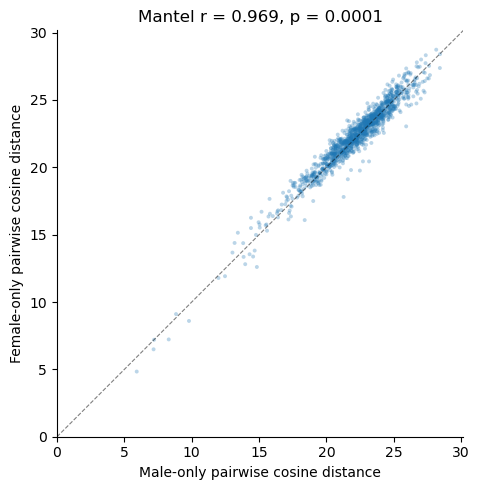

In [23]:
# ---------- 7. Scatter plot: male vs female pairwise distances ----------
import matplotlib.pyplot as plt
import seaborn as sns

male_dists = squareform(dm_male.data)
female_dists = squareform(dm_female.data)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(male_dists, female_dists, alpha=0.3, s=8, edgecolors="none")
lims = [0, max(male_dists.max(), female_dists.max()) * 1.05]
ax.plot(lims, lims, "k--", lw=0.8, alpha=0.5)
ax.set_xlabel("Male-only pairwise cosine distance")
ax.set_ylabel("Female-only pairwise cosine distance")
ax.set_title(f"Mantel r = {coeff:.3f}, p = {p_value:.4f}")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal")
sns.despine()
plt.tight_layout()
plt.show()

## FLEURS vs FLEURS-R: does speech restoration bias embeddings?

Mantel test on per-language pairwise distance matrices from raw XLS-R embeddings (no projection head), comparing original FLEURS and speech-restored FLEURS-R.

In [2]:
# ---------- 8. FLEURS vs FLEURS-R: Mantel test on raw XLS-R embeddings ----------
import json
import numpy as np
import pandas as pd
import torch
from scipy.spatial.distance import pdist, squareform
from skbio import DistanceMatrix
from skbio.stats.distance import mantel

FLEURS_R_DIR = "data/embeddings/fleurs-r/67c9af47-6177-4d06-bcc5-7c64b43e4b06"
FLEURS_DIR = "data/embeddings/fleurs/d9ac427f-5569-497f-99ac-3ecf6226ef15"

ie_dirs = sorted(
    pd.read_csv("data/metadata/fleurs-r/glottolog.csv")
    .query("H0 == 'indo1319'")["fleurs_dir"]
)

def load_lang_means(emb_dir):
    emb = torch.load(f"{emb_dir}/embeddings.pt", weights_only=True).float().numpy()
    meta = pd.read_parquet(f"{emb_dir}/meta.parquet")
    with open(f"{emb_dir}/taxa.json") as f:
        labels = json.load(f)["labels"]
    meta["fleurs_dir"] = meta["label"].map(lambda i: labels[i])
    means = {}
    for fd in ie_dirs:
        mask = meta["fleurs_dir"] == fd
        means[fd] = emb[mask.values].mean(axis=0)
    return np.stack([means[fd] for fd in ie_dirs])

mean_r = load_lang_means(FLEURS_R_DIR)
mean_f = load_lang_means(FLEURS_DIR)

print(f"FLEURS-R means: {mean_r.shape}, FLEURS means: {mean_f.shape}")

dm_r = DistanceMatrix(squareform(pdist(mean_r, metric="cosine")), ids=ie_dirs)
dm_f = DistanceMatrix(squareform(pdist(mean_f, metric="cosine")), ids=ie_dirs)

coeff, p_value, n = mantel(dm_r, dm_f, method="pearson", permutations=9999)
print(f"\n=== Mantel test: FLEURS-R vs FLEURS (raw XLS-R, cosine, {n} IE languages) ===")
print(f"  Pearson r  = {coeff:.4f}")
print(f"  p-value    = {p_value:.4f}")

FLEURS-R means: (51, 1024), FLEURS means: (51, 1024)

=== Mantel test: FLEURS-R vs FLEURS (raw XLS-R, cosine, 51 IE languages) ===
  Pearson r  = 0.9951
  p-value    = 0.0001


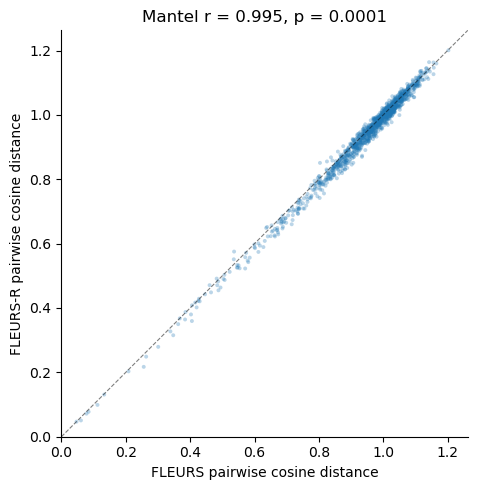

In [3]:
# ---------- 9. Scatter: FLEURS-R vs FLEURS pairwise distances ----------
import matplotlib.pyplot as plt
import seaborn as sns

dists_r = squareform(dm_r.data)
dists_f = squareform(dm_f.data)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(dists_f, dists_r, alpha=0.3, s=8, edgecolors="none")
lims = [0, max(dists_r.max(), dists_f.max()) * 1.05]
ax.plot(lims, lims, "k--", lw=0.8, alpha=0.5)
ax.set_xlabel("FLEURS pairwise cosine distance")
ax.set_ylabel("FLEURS-R pairwise cosine distance")
ax.set_title(f"Mantel r = {coeff:.3f}, p = {p_value:.4f}")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal")
sns.despine()
plt.tight_layout()
plt.show()